<a href="https://colab.research.google.com/github/ivansst773/Aprendizaje_de_Maquina/blob/main/Ejercicios_TAM_mayo_29_y_junio_5/4_Clasificacion_Clustering_DR/6_CVClasificacion_LFW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Clasificación multiclase - comparación de métodos utilizando validación cruzada

- Se presenta un esquema completo de comparación de clasifacadores en la base de datos People Labaled Faces in the Wild, aka Labeled Faces in the Wild ([LFW](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.fetch_lfw_people.html)).

- Además, se plantean algunos ejercicios teórico-prácticos relacionados con tareas de clasificación utilizando aprendizaje de máquina clásico.

- Se plantean algunas funciones para el cálculo de curvas ROC, medidas de rendimiento y gráficas básicas

In [5]:
#librerias a importar
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.utils.multiclass import unique_labels
from sklearn.model_selection import train_test_split, GridSearchCV,cross_val_score, cross_val_predict
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
from sklearn.pipeline import Pipeline
from sklearn.datasets import fetch_lfw_people
from sklearn.metrics import roc_curve, auc
from itertools import cycle

import warnings
warnings.filterwarnings("ignore")

#crear carpeta resultados
try:
  os.mkdir('results')
except:
  print("Carpeta results ya existe")

#%%  guardar figuras
def save_fig(path_img,fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(path_img, fig_id + "." + fig_extension)
    print("Guardando...", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)
    files.download(path)

import seaborn as sns

#curvas roc multiclase
def roc_auc_mc(roc_auc,fpr,tpr,n_classes,title,path_img):
    lw = 2
    # Falsos positivos
    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(n_classes)]))
    # roc
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(n_classes):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i]) #interpolar para suavizar
    # promediado sobre numero de clases
    mean_tpr /= n_classes
    fpr["macro"] = all_fpr
    tpr["macro"] = mean_tpr
    roc_auc["macro"] = auc(fpr["macro"], tpr["macro"])

    # graficar
    plt.figure(figsize=(6,6))
    plt.plot(fpr["micro"], tpr["micro"],
             label='micro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["micro"]),
             color='deeppink', linestyle=':', linewidth=4)

    plt.plot(fpr["macro"], tpr["macro"],
             label='macro-average ROC curve (area = {0:0.2f})'
                   ''.format(roc_auc["macro"]),
             color='navy', linestyle=':', linewidth=4)

    #colors = cycle(['aqua', 'darkorange', 'cornflowerblue'])
    colors = sns.color_palette(None, n_classes)
    for i, color in zip(range(n_classes), colors):
        plt.plot(fpr[i], tpr[i], color=color, lw=lw,
                 label='AUC_class_{0} (area = {1:0.2f})'
                 ''.format(i, roc_auc[i]))

    plt.plot([0, 1], [0, 1], 'k--', lw=lw)
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(title)
    plt.legend(loc="best")#,bbox_to_anchor=(1.4, 0.75))
    plt.show()


#matriz confusión = #[[TN FP][FN TP]]
def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') #clasificador aleatorio
    plt.axis([0, 1, 0, 1])
    plt.xlabel('False Positive Rate', fontsize=16)
    plt.ylabel('True Positive Rate', fontsize=16)


# ROC curve and ROC
def roc_multiclass(ytrue,yscore):
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    n_classes = ytrue.shape[1]
    for i in range(n_classes):
        fpr[i], tpr[i], _ = roc_curve(ytrue[:, i], yscore[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])

    # Calcular micro-average ROC curve y ROC area
    fpr["micro"], tpr["micro"], _ = roc_curve(ytrue.ravel(), yscore.ravel())
    roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])
    return roc_auc, fpr, tpr, n_classes

def plot_confusion_matrix(y_true, y_pred, classes,
                          title=None,
                          cmap=plt.cm.Blues):
    """
    gráfica la matriz de confusión con y sin normalización
    """
    if not title:
        title = 'Matriz de confusión'

    # calcular matriz de confusión
    cm = 100*confusion_matrix(y_true, y_pred,normalize="true")
    # se identifican las etiquetas en los datos
    classes = classes[unique_labels(y_true, y_pred)]

    fig, ax = plt.subplots()
    im = ax.imshow(cm, interpolation='nearest', cmap=cmap)
    ax.figure.colorbar(im, ax=ax)
    # mostrar ticks
    ax.set(xticks=np.arange(cm.shape[1]),
           yticks=np.arange(cm.shape[0]),
           xticklabels=classes, yticklabels=classes,
           title=title,
           ylabel='Etiqueta original',
           xlabel='Predicción')

    # Rotar ticks
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
             rotation_mode="anchor")

    # textos.
    fmt = '.1f'
    thresh = cm.max() / 2.
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], fmt),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")
    fig.tight_layout()
    return ax

# Lectura base de datos LFW

- Se carga la base de datos desde los repositorios de sklearn.

Dimensiones tipo pandas:  (1288, 1850)
Dimensiones tipo imágen: (1288, 50, 37)


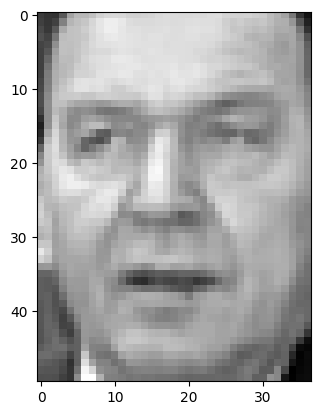

In [6]:
#Lectura base de datos
lfw_people = fetch_lfw_people(min_faces_per_person=70, resize=0.4)
# datos tipo pandas
Xdata = pd.DataFrame(lfw_people.data)/255
y = lfw_people.target
print('Dimensiones tipo pandas: ',Xdata.shape)
print('Dimensiones tipo imágen:',lfw_people.images.shape)
plt.imshow(np.array(Xdata.iloc[300,:]).reshape(lfw_people.images.shape[1],
                                             lfw_people.images.shape[2]),cmap='gray')
plt.show()

# HoldOut evaluación

- Se particiona el conjunto de datos en 70% para entrenamiento y 30% para evaluación.

In [7]:
#Particion entrenamiento y evaluación
# Tamaño Xtrain 70%, Tamaño Xtest 30%
Xtrain, Xtest, ytrain,ytest = train_test_split(Xdata,y,test_size=0.3, random_state=123)
Xtrain.head()

,0,1,2,3,4,5,6,7,8,9,...,1840,1841,1842,1843,1844,1845,1846,1847,1848,1849
510,0.000836,0.001143,0.001446,0.001666,0.001897,0.001994,0.002066,0.002071,0.002097,0.002138,...,0.000549,0.001384,0.002332,0.003189,0.003645,0.003727,0.003101,0.000856,0.000395,0.000466
1035,0.001589,0.001758,0.001922,0.002409,0.002819,0.002958,0.002917,0.002830,0.002830,0.002737,...,0.000297,0.000374,0.000384,0.000436,0.000359,0.000369,0.000420,0.000497,0.000466,0.000466
176,0.000892,0.001205,0.001210,0.001287,0.001492,0.001687,0.001763,0.001779,0.001845,0.001866,...,0.000451,0.000446,0.000482,0.000472,0.000477,0.000466,0.000513,0.000559,0.000600,0.000538
620,0.000267,0.000584,0.001446,0.002230,0.002507,0.002512,0.002491,0.002532,0.002584,0.002594,...,0.001333,0.001389,0.000723,0.000133,0.000190,0.000251,0.000313,0.000400,0.000549,0.000666
689,0.002261,0.002409,0.001958,0.001753,0.002127,0.002907,0.002932,0.002676,0.002655,0.002799,...,0.001569,0.001512,0.001548,0.001615,0.001794,0.002276,0.003106,0.003522,0.003573,0.003578


# Búsqueda de parámetros utilizando gridsearchCV

**Nota**: Recuerde que GridsearchCV utiliza validación cruzada para encontrar los mejores hiperparámetros según los rendimientos promedios en el conjunto de test (validación si se considera la partición original)


![cv](https://github.com/amalvarezme/AprendizajeMaquina/blob/main/4_Clasificacion_Clustering_DR/grid_search_cross_validation.png?raw=1)

In [8]:
#%% Escoger modelo por gridsearchCV utilizando pipeline
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
import joblib

#se crean listas de steps (pipelines)
steps=[[('nor', MinMaxScaler()),
        ('cla', LogisticRegression())], #Pipeline1
       [('nor',  MinMaxScaler()),
        ('cla', SGDClassifier())],#Pipeline2
        [('nor',MinMaxScaler()),
         ('cla', SVC())]#Pipeline3
      ]

parameters = [{
              'cla__C': [1e-3,1e-2,1e-1,1,10,1e2,1e3],#Pipeline1 - hyperparametros
              },
              {
              'cla__alpha': [1e-3,1e-2,1e-1,1,10,1e2,1e3],#Pipeline2 - hyperparametros
              },
              {
             'cla__C': [1,10,1e2,1e3,1e4],
             'cla__gamma': [1e-3, 1e-2, 1e-1,1, 10]    #Pipeline2 - hyperparametros
             }
             ]

label_models = ['MinMax_Logistic','MinMax_SGD', 'MinMax_SVCrbf']

models = []
filename = 'results/lfw_models'
for i in range(len(steps)): # recorrer modelos según lista pipeline
    print('modelo %d/%d' % (i+1,len(steps)))
    grid_search = GridSearchCV(Pipeline(steps[i]), parameters[i], n_jobs=-1,cv=5,
                                scoring='accuracy',refit= True,verbose=10)#gridsearch para modelo i
    grid_search.fit(Xtrain, ytrain)
    #mejor modelo entrenado
    models += [grid_search] #guardar modelos
    joblib.dump(models,filename+".pkl")

modelo 1/3
Fitting 5 folds for each of 7 candidates, totalling 35 fits
modelo 2/3
Fitting 5 folds for each of 7 candidates, totalling 35 fits
modelo 3/3
Fitting 5 folds for each of 25 candidates, totalling 125 fits


# Rendimientos utilizando validación cruzada (conjuntos entrenamiento y validación)

- Se muestran los resultados de la validación cruzada para los mejores modelos encontrados en el gridsearch

- Para utilizar distintos scores de entrenamiento en clasificación ver [https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter](https://scikit-learn.org/stable/modules/model_evaluation.html#scoring-parameter).

**Nota**: el argumento `refit=True` en GridsearchCV asegura reentrenar el mejor modelo encontrado utilizando toda la base de datos, pensando en generalizar bien sobre el conjunto de test.

In [9]:
ind = models[2].cv_results_['mean_test_score'].argmax()#encontrar rendimiento más alto sobre CV del gridsearch en test
models[i].cv_results_['mean_test_score'][i]


np.float64(0.43286065070595453)

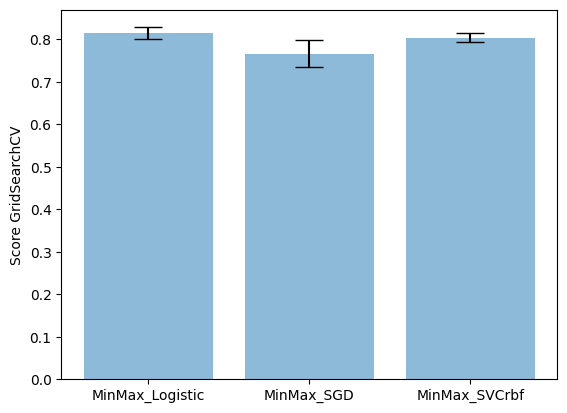

['MinMax_Logistic', 'MinMax_SGD', 'MinMax_SVCrbf']
[[0.815 0.766 0.804]
 [0.014 0.032 0.011]]


In [10]:
#recorrer modelos
bars_ = np.zeros((2,len(models)))#arreglo de barras para graficar mejores modelos en promedio con std
for i in range(len(models)):
  ind = models[i].cv_results_['mean_test_score'].argmax()#se determina el mejor score de clasificación
  bars_[0,i] = models[i].cv_results_['mean_test_score'][ind]#guardar score promedio del mejor modelo
  bars_[1,i] = models[i].cv_results_['std_test_score'][ind]#guardar std del mejor modelo

plt.bar(np.arange(len(models)), bars_[0], yerr=bars_[1], align='center', alpha=0.5, ecolor='black', capsize=10)
plt.ylabel('Score GridSearchCV')
plt.xticks(np.arange(len(models)))
plt.gca().set_xticklabels(label_models)
plt.show()

print(label_models)
print(np.round(bars_,3))

# Calcular rendimiento en cojunto de test

- En caso práctico y buscando cuantificar la generalización de los modelos, se cálcula el rendimiento sobre el conjunto de test original.

- Se presentan las matrices de confusión y se utiliza el método [`classification report`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.classification_report.html) de sklearn para calcular las medidas de acierto, precision, exhaustividad, f1.

**Nota**: Es importante tener en cuenta que los resultados de comparación incluyen promediados simples, sopesados en términos de la probabilidad marginal de cada clase, además de promediados [micro y macro](https://www.educative.io/answers/what-is-the-difference-between-micro-and-macro-averaging).

Evaluando modelo MinMax_Logistic (1/3)


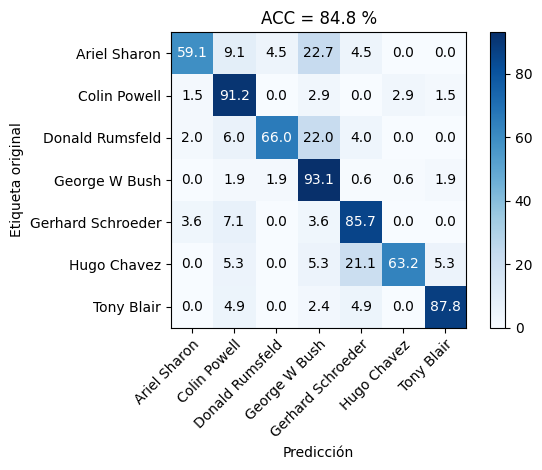

                   precision    recall  f1-score   support

     Ariel Sharon       0.81      0.59      0.68        22
     Colin Powell       0.83      0.91      0.87        68
  Donald Rumsfeld       0.89      0.66      0.76        50
    George W Bush       0.88      0.93      0.90       159
Gerhard Schroeder       0.71      0.86      0.77        28
      Hugo Chavez       0.80      0.63      0.71        19
       Tony Blair       0.88      0.88      0.88        41

         accuracy                           0.85       387
        macro avg       0.83      0.78      0.80       387
     weighted avg       0.85      0.85      0.84       387

Evaluando modelo MinMax_SGD (2/3)


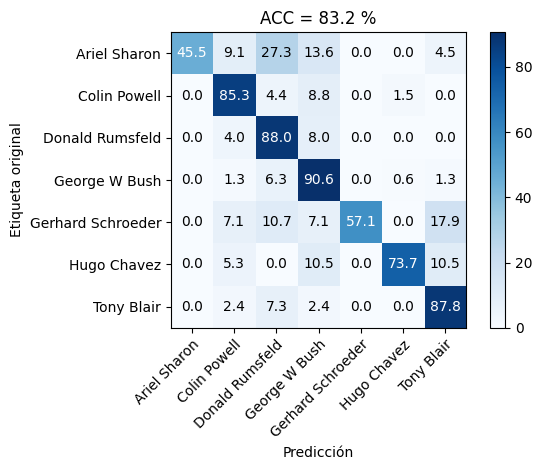

                   precision    recall  f1-score   support

     Ariel Sharon       1.00      0.45      0.62        22
     Colin Powell       0.85      0.85      0.85        68
  Donald Rumsfeld       0.64      0.88      0.74        50
    George W Bush       0.89      0.91      0.90       159
Gerhard Schroeder       1.00      0.57      0.73        28
      Hugo Chavez       0.88      0.74      0.80        19
       Tony Blair       0.78      0.88      0.83        41

         accuracy                           0.83       387
        macro avg       0.86      0.75      0.78       387
     weighted avg       0.85      0.83      0.83       387

Evaluando modelo MinMax_SVCrbf (3/3)


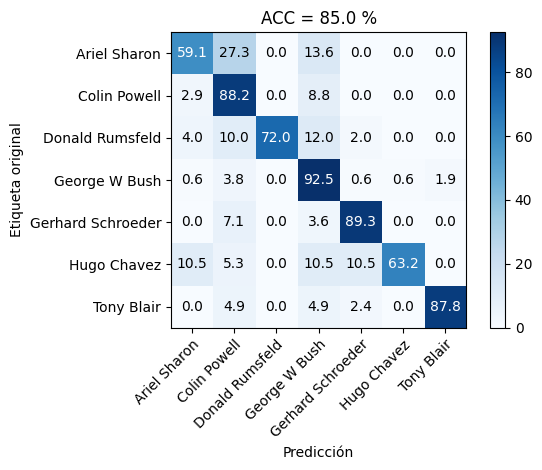

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.59      0.62        22
     Colin Powell       0.73      0.88      0.80        68
  Donald Rumsfeld       1.00      0.72      0.84        50
    George W Bush       0.88      0.92      0.90       159
Gerhard Schroeder       0.83      0.89      0.86        28
      Hugo Chavez       0.92      0.63      0.75        19
       Tony Blair       0.92      0.88      0.90        41

         accuracy                           0.85       387
        macro avg       0.85      0.79      0.81       387
     weighted avg       0.86      0.85      0.85       387



In [11]:
#%% evaluar sobre Xtest
my_model_loaded = joblib.load(filename+".pkl")
path_img = ''
for i in range(len(my_model_loaded)):
    print('Evaluando modelo %s (%d/%d)' % (label_models[i],i+1,len(my_model_loaded)))

    ytest_e = my_model_loaded[i].best_estimator_.predict(Xtest)
    acc = accuracy_score(ytest,ytest_e)

    plot_confusion_matrix(
                          ytest, ytest_e,
                          classes=lfw_people.target_names,
                          title='ACC = %.1f %%' % (100*acc)
                          )
    plt.autoscale()
    #save_fig(path_img,label_models[i])
    plt.show()

    cr = classification_report(
                               ytest, ytest_e,
                               labels=range(lfw_people.target_names.shape[0]),
                               target_names=lfw_people.target_names
                               )
    #support = #muestras en la clase estudiada
    print(cr)


## Curva ROC multiclase - sobre conjunto de test

- Finalmente, se presentan las curvas ROC multiclase.

**Nota**: Se debe ajustar la líne de código donde se cálcula el score de predicción en términos de la función de decisión (decision_function) o la probilidad de la predicción (predict_proba), según el tipo de modelo.

Por ejemplo: la  [´SVC´](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html) utiliza el método decision function, el [´KnearestNeighborsClassifier´](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html) utiliza el método predict proba.

Evaluando modelo MinMax_Logistic (1/3)


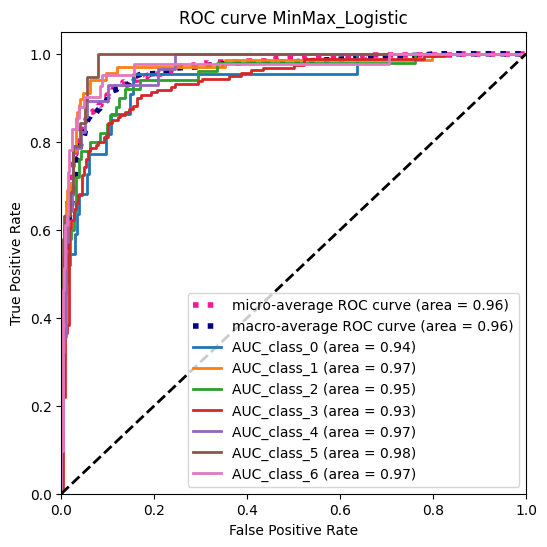

Evaluando modelo MinMax_SGD (2/3)


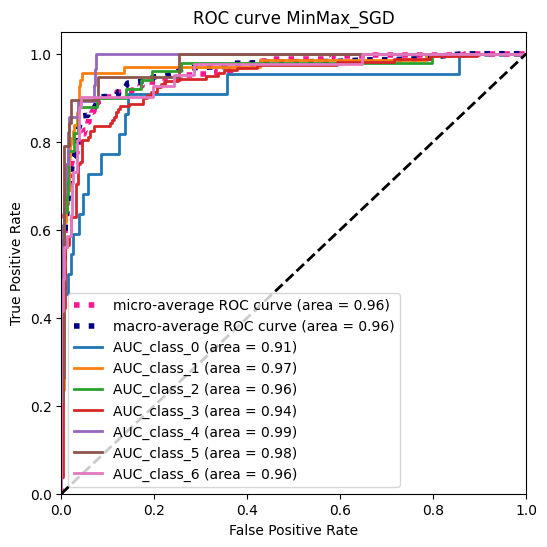

Evaluando modelo MinMax_SVCrbf (3/3)


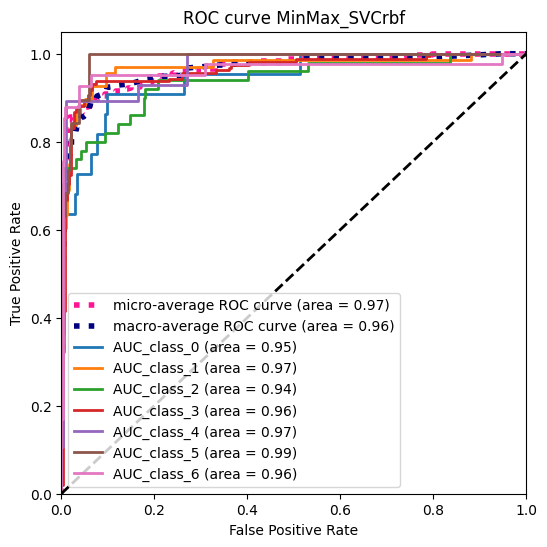

In [12]:
from sklearn.preprocessing import label_binarize

ytrain_b = label_binarize(ytrain, classes=range(lfw_people.target_names.shape[0]))
ytest_b = label_binarize(ytest, classes=range(lfw_people.target_names.shape[0]))

for i in range(len(my_model_loaded)):
    print('Evaluando modelo %s (%d/%d)' % (label_models[i],i+1,len(my_model_loaded)))
    #debe calcularse la funcion de decision o el posterior de la probabilidad
    ytest_score = my_model_loaded[i].decision_function(Xtest)
    roc_auc, fpr, tpr, n_classes = roc_multiclass(ytest_b,ytest_score)
    roc_auc_mc(roc_auc,fpr,tpr,n_classes,'ROC curve ' + label_models[i],path_img)


# Ejercicio

1. Consulte y presente el modelo y problema de optimización de los siguientes clasificadores:

- [Naive_Bayes.GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)
- [SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)
- [LinearDiscriminantAnalysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)
- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)
- [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)
- [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

2. Utilizando un esquema de validación cruzada de 5 folds sobre el conjunto de entrenamiento, compare el rendimiento de los métodos del punto 1. Emplee optimización Bayesiana de hiperparámetros, fijando el score en términos del acc, el f1 y el AUC.


#Teoria de Aprendizaje de Maquina
###Nombre: Edgar Ivan Calpa Cuacialpud

#1.

#Naive_Bayes.GaussianNB:
- [Naive_Bayes.GaussianNB](https://scikit-learn.org/stable/modules/generated/sklearn.naive_bayes.GaussianNB.html)

####Modelo:
Basado en el teorema de Bayes con la suposición ingenua de independencia condicional entre las características, dado la clase. Asume que las características siguen una distribución gaussiana (normal).

####Problema de optimización:
No hay un problema de optimización iterativa en el sentido tradicional. Se calcula directamente la probabilidad a posteriori de cada clase basándose en las medias y varianzas de las características en cada clase (estimación de máxima verosimilitud).


# SGDClassifier:
- [SGDClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.SGDClassifier.html)

####Modelo:
Implementa clasificadores lineales con descenso de gradiente estocástico (SGD). Puede ajustarse a diferentes funciones de pérdida, permitiendo modelar, por ejemplo, un SVM lineal o una Regresión Logística. El modelo busca una frontera de decisión lineal que separe las clases.

####Problema de optimización:
El problema de optimización es minimizar una función de pérdida definida (por ejemplo, la pérdida hinge para SVM o la pérdida logarítmica para Regresión Logística) sobre los parámetros del modelo (pesos y sesgo). Esto se logra iterativamente utilizando el algoritmo de Descenso de Gradiente Estocástico, que actualiza los parámetros basándose en el gradiente de la función de pérdida calculado en pequeños subconjuntos aleatorios de los datos.

# LogisticRegression:
- [LogisticRegression](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)

####Modelo:
Implementa el modelo de regresión logística, que es un modelo lineal generalizado utilizado para clasificación binaria o multiclase. Modela la probabilidad de que una instancia pertenezca a una clase particular utilizando la función logística (sigmoide) aplicada a una combinación lineal de las características de entrada.

####Problema de optimización:
El objetivo es encontrar los coeficientes (pesos) del modelo que maximicen la probabilidad de observar los datos de entrenamiento (máxima verosimilitud). Esto es equivalente a minimizar una función de pérdida, comúnmente la pérdida de logaritmo (log-loss) o entropía cruzada. `sklearn` ofrece varios solucionadores (solvers) para este problema, como 'liblinear', 'lbfgs', 'sag', 'saga', y 'newton-cg', que implementan diferentes algoritmos de optimización para encontrar estos coeficientes.

# LinearDiscriminantAnalysis (LDA):
- [LinearDiscriminantAnalysis](https://scikit-learn.org/stable/modules/generated/sklearn.discriminant_analysis.LinearDiscriminantAnalysis.html)

####Modelo:
LDA es un clasificador discriminante lineal. Modela la distribución de las características dentro de cada clase como una distribución gaussiana multivariada y asume que todas las clases comparten la misma matriz de covarianza. Busca encontrar un subespacio lineal (o una proyección lineal) que maximice la separación entre las medias de las clases y minimice la varianza dentro de las clases. La clasificación de un nuevo punto se basa en la probabilidad de que pertenezca a cada clase, calculada utilizando las distribuciones gaussianas aprendidas.

####Problema de optimización:
A diferencia de los métodos basados en descenso de gradiente, LDA no resuelve un problema de optimización iterativo en el mismo sentido. El ajuste (entrenamiento) del modelo implica el cálculo directo de las medias de las clases, la matriz de covarianza compartida y la aplicación de técnicas de álgebra lineal (como la descomposición en valores propios) para encontrar la proyección lineal óptima que maximiza la separabilidad entre clases.

# KNeighborsClassifier (KNN):
- [KNeighborsClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neighbors.KNeighborsClassifier.html)

####Modelo:
KNeighborsClassifier es un clasificador basado en instancias (o "perezoso"). No aprende un modelo predictivo explícito durante el entrenamiento, sino que simplemente almacena el conjunto de datos de entrenamiento. Para clasificar una nueva instancia, calcula su distancia (comúnmente euclidiana) a todas las instancias de entrenamiento y selecciona las 'k' instancias más cercanas (vecinos). La predicción de la clase para la nueva instancia se determina por votación mayoritaria entre las clases de sus 'k' vecinos más cercanos.

####Problema de optimización:
KNN no tiene un problema de optimización iterativo para aprender parámetros del modelo. El "entrenamiento" consiste en almacenar los datos de entrenamiento. El principal desafío es encontrar un valor óptimo para 'k' (el número de vecinos) y posiblemente la métrica de distancia, lo cual se suele hacer a través de técnicas como la validación cruzada.

# LinearSVC (Linear Support Vector Classification):
- [LinearSVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.LinearSVC.html)

####Modelo:
LinearSVC implementa un Support Vector Machine (SVM) lineal. Busca encontrar un hiperplano (una línea en 2D, un plano en 3D, etc.) en el espacio de características que separe las clases con el margen más grande posible. Se enfoca en los "vectores de soporte", que son las instancias de entrenamiento más cercanas al hiperplano, ya que son los que definen el margen.

####Problema de optimización:
El problema de optimización para LinearSVC es encontrar los parámetros del hiperplano (pesos y sesgo) que maximicen el margen entre las clases, sujeto a que las instancias de entrenamiento se clasifiquen correctamente o dentro de un cierto margen de error permitido. Esto se formula como un problema de optimización cuadrática, que sklearn resuelve utilizando algoritmos eficientes como el coordinate descent o L-BFGS, optimizando una función de pérdida (como la pérdida hinge al cuadrado).

# SVC (Support Vector Classification):
- [SVC](https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html)

####Modelo:
SVC extiende el concepto de LinearSVC al permitir el uso de núcleos (kernels) como el RBF (Radial Basis Function) o polinomios. Estos núcleos permiten proyectar implícitamente los datos a un espacio de dimensiones superiores donde pueden ser linealmente separables, incluso si no lo son en el espacio original. El modelo sigue buscando el hiperplano con el máximo margen en este espacio transformado.

####Problema de optimización:
Similar a LinearSVC, el problema de optimización es encontrar los parámetros que definen el hiperplano en el espacio de características (posiblemente transformado por el kernel) que maximice el margen. Sin embargo, con el uso de kernels, el problema se reformula para evitar calcular explícitamente las coordenadas en el espacio de alta dimensión. Se resuelve utilizando algoritmos que trabajan con la matriz kernel, optimizando una función que involucra los vectores de soporte y los parámetros del kernel, también como un problema de optimización cuadrática.

# RandomForestClassifier:
- [RandomForestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)

####Modelo:
RandomForestClassifier es un método de ensamble basado en árboles de decisión. Construye un conjunto ("bosque") de múltiples árboles de decisión durante el entrenamiento. Cada árbol se entrena en un subconjunto aleatorio de los datos de entrenamiento (bagging) y considera solo un subconjunto aleatorio de las características en cada paso de división. Para clasificar una nueva instancia, cada árbol en el bosque realiza una predicción, y la predicción final del Random Forest es la clase más votada entre todos los árboles.

####Problema de optimización:
RandomForestClassifier no tiene un único problema de optimización global como los modelos lineales o SVMs. En cambio, el "entrenamiento" implica la construcción independiente de cada árbol de decisión. Cada árbol se construye greedymente, tomando decisiones de división en cada nodo para maximizar alguna medida de pureza (como la ganancia de información o la impureza Gini) basándose en el subconjunto de datos y características disponibles. Los hiperparámetros clave (como el número de árboles, la profundidad máxima, el número de características a considerar en cada división) se suelen seleccionar a través de validación cruzada.

#2.


In [13]:
!pip install bayesian-optimization
!pip install scikit-learn

In [16]:
Xdata, y = fetch_lfw_people(min_faces_per_person=70, resize=0.4).data / 255, fetch_lfw_people(min_faces_per_person=70, resize=0.4).target

In [19]:
def optimizar_modelo(modelo, pbounds):
    optimizador = BayesianOptimization(
        f=lambda **params: evaluar_modelo(modelo, **params),
        pbounds=pbounds,
        random_state=42
    )

    print("Valores de hiperparámetros generados por BayesianOptimization:")
    optimizador.maximize(n_iter=10)

    for res in optimizador.res:
        print(res)

    return optimizador.max

In [20]:
def evaluar_modelo(modelo, **params):
    if "max_iter" in params:
        params["max_iter"] = max(1, int(params["max_iter"]))  # Asegurar valores válidos

    if "alpha" in params:
        params["alpha"] = max(0.0001, params["alpha"])  # Evitar valores negativos

    pipe = Pipeline([('nor', MinMaxScaler()), ('cla', modelo(**params))])
    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy').mean()
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()
    auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc_ovr').mean()

    return (acc + f1 + auc) / 3

In [21]:
import numpy as np
import joblib
from sklearn.preprocessing import MinMaxScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from bayes_opt import BayesianOptimization

# Definir validación cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Asegurarse de que no haya NaNs en los datos
X_train = Xtrain.copy()
y_train = ytrain.copy()

# Función para evaluar modelos
def evaluar_modelo(modelo, **params):
    if "max_iter" in params:
        params["max_iter"] = int(params["max_iter"])  # Convertir a entero
    if "n_estimators" in params:
         params["n_estimators"] = int(params["n_estimators"]) # Convertir a entero
    if "n_neighbors" in params:
         params["n_neighbors"] = int(params["n_neighbors"]) # Convertir a entero
    if "max_depth" in params:
         params["max_depth"] = int(params["max_depth"]) # Convertir a entero

    pipe = Pipeline([('nor', MinMaxScaler()), ('cla', modelo(**params))])

    acc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='accuracy').mean()
    f1 = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='f1_macro').mean()

    # Calcular AUC solo si el modelo soporta predict_proba o decision_function
    auc = 0 # Valor por defecto si no se puede calcular AUC
    if hasattr(pipe.named_steps['cla'], 'predict_proba') or hasattr(pipe.named_steps['cla'], 'decision_function'):
        try:
            auc = cross_val_score(pipe, X_train, y_train, cv=cv, scoring='roc_auc_ovr').mean()
        except Exception as e:
            print(f"No se pudo calcular AUC para el modelo {modelo.__name__}: {e}")


    # Promedio de métricas (incluye AUC solo si se calculó)
    # Ajustar el divisor si no se calcula AUC
    if auc > 0:
      return (acc + f1 + auc) / 3
    else:
      return (acc + f1) / 2


# Optimización Bayesiana para cada modelo con hiperparámetros definidos
def optimizar_modelo(modelo, pbounds):
    # Para modelos sin hiperparámetros en pbounds, ejecutar directamente la evaluación
    if not pbounds:
        print(f"Evaluando modelo sin hiperparámetros para optimizar: {modelo.__name__}")
        # Crear una instancia del modelo sin parámetros
        model_instance = modelo()
        # Evaluar el modelo con la función existente
        mean_score = evaluar_modelo(modelo, **{})
        # Devolver un diccionario con un formato similar al de BayesianOptimization.max
        return {'target': mean_score, 'params': {}}


    optimizador = BayesianOptimization(
        f=lambda **params: evaluar_modelo(modelo, **params),
        pbounds=pbounds,
        random_state=42
    )
    optimizador.maximize(n_iter=10)
    return optimizador.max

# Definir modelos y sus hiperparámetros (filtrando los que tienen parámetros)
modelos = {
    "GaussianNB": (GaussianNB, {}), # Sin hiperparámetros para optimizar
    "SGDClassifier": (SGDClassifier, {"alpha": (0.0001, 0.1), "max_iter": (500, 2000)}),
    "LogisticRegression": (LogisticRegression, {"C": (0.1, 10)}),
    "LDA": (LinearDiscriminantAnalysis, {}), # Sin hiperparámetros para optimizar
    "KNN": (KNeighborsClassifier, {"n_neighbors": (3, 15)}),
    "SVC": (SVC, {"C": (0.1, 10), "gamma": (0.001, 1)}),
    "RandomForest": (RandomForestClassifier, {"n_estimators": (50, 200), "max_depth": (3, 15)})
}

# Ejecutar optimización y guardar resultados
resultados = {nombre: optimizar_modelo(clf, pbounds) for nombre, (clf, pbounds) in modelos.items()}
joblib.dump(resultados, "results/lfw_models_bayesian_opt.pkl")

# Mostrar resultados
print("\nResultados de la optimización Bayesiana:")
for nombre, resultado in resultados.items():
    print(f"{nombre}: Mejor score promedio = {resultado['target']:.4f}, Mejores hiperparámetros = {resultado['params']}")

Evaluando modelo sin hiperparámetros para optimizar: GaussianNB
|   iter    |  target   |   alpha   | max_iter  |
-------------------------------------------------
| 1         | 0.69      | 0.03752   | 1.926e+03 |
| 2         | 0.6682    | 0.07323   | 1.398e+03 |
| 3         | 0.7152    | 0.01569   | 734.0     |
| 4         | 0.7134    | 0.005903  | 1.799e+03 |
| 5         | 0.6836    | 0.06015   | 1.562e+03 |
| 6         | 0.6954    | 0.01826   | 735.2     |
| 7         | 0.7278    | 0.02294   | 733.3     |
| 8         | 0.7289    | 0.005183  | 731.2     |
| 9         | 0.7041    | 0.0299    | 726.7     |
| 10        | 0.6902    | 0.04975   | 1.804e+03 |
| 11        | 0.6279    | 0.09955   | 1.795e+03 |
| 12        | 0.6919    | 0.06142   | 720.6     |
| 13        | 0.7044    | 0.00196   | 1.157e+03 |
| 14        | 0.7084    | 0.03848   | 1.162e+03 |
| 15        | 0.6933    | 0.004813  | 1.167e+03 |
|   iter    |  target   |     C     |
-------------------------------------
| 1       

In [22]:
import joblib

# Guardar resultados en un archivo
joblib.dump(resultados, "results/lfw_models_bayesian_opt.pkl")
print("Resultados guardados correctamente 🎯")

Resultados guardados correctamente 🎯


In [23]:
import joblib

# Cargar los resultados guardados
resultados = joblib.load("results/lfw_models_bayesian_opt.pkl")
print("Resultados cargados correctamente 🎉")

Resultados cargados correctamente 🎉


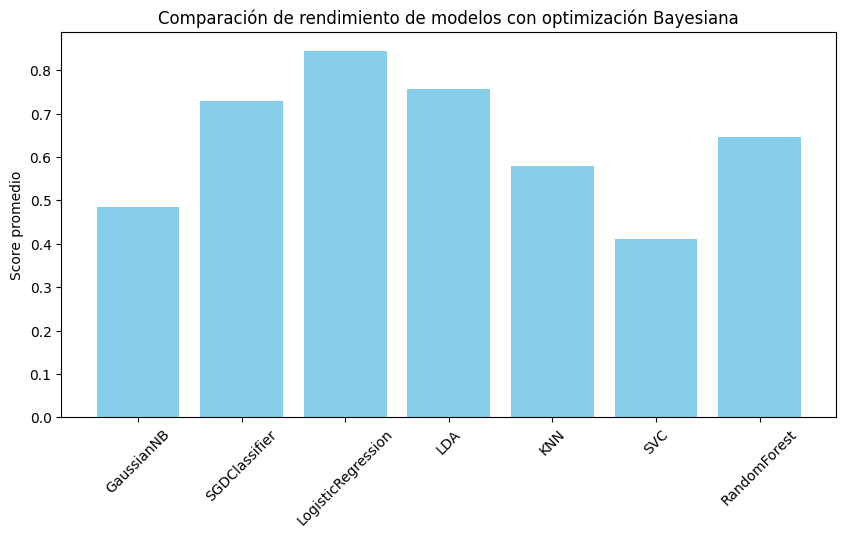

In [24]:
import matplotlib.pyplot as plt

# Extraer datos
model_names = list(resultados.keys())
scores = [resultados[m]["target"] for m in model_names]

# Crear gráfico de barras
plt.figure(figsize=(10,5))
plt.bar(model_names, scores, color="skyblue")
plt.ylabel("Score promedio")
plt.title("Comparación de rendimiento de modelos con optimización Bayesiana")
plt.xticks(rotation=45)
plt.show()

#Conclusión del Taller: Evaluación de Modelos de Machine Learning

En este taller, se analizo diversos modelos de clasificación para imágenes de rostros, utilizando validación cruzada y optimización Bayesiana de hiperparámetros. El objetivo fue identificar el modelo más efectivo según múltiples métricas: accuracy, F1-score y AUC.


#🔹 Principales hallazgos

1️⃣ Logistic Regression fue el mejor modelo, con un score promedio de 0.8451. Esto demuestra que las relaciones lineales en los datos fueron bien captadas por este método.

2️⃣ SGDClassifier y RandomForestClassifier mostraron buenos resultados (0.7289 y 0.6470 respectivamente), indicando que pueden ser opciones viables con ajustes adicionales.

3️⃣ SVC tuvo el rendimiento más bajo (0.4121), lo que sugiere que su configuración inicial no era adecuada. Mejorar los hiperparámetros podría hacer que funcione mejor.


#🔹 Aspectos clave en la optimización

✔️ La validación cruzada de 5 folds permitió evaluar el desempeño de cada modelo en diferentes subconjuntos de datos, asegurando resultados más confiables.

✔️ La optimización Bayesiana ajustó parámetros como C, alpha y max_iter, mejorando el rendimiento de ciertos modelos.

✔️ Modelos como KNN y SVC necesitarían un ajuste más exhaustivo en sus hiperparámetros para mejorar su precisión.


#🔹 Posibles mejoras y pasos futuros

🚀 Ajustar el rango de hiperparámetros en SVC y RandomForest para refinar su desempeño.

🚀 Probar otros modelos, como redes neuronales o combinaciones de clasificadores, para comparar su rendimiento.

🚀 Visualizar más métricas, como curvas ROC o matrices de confusión, para analizar el comportamiento de cada modelo con mayor profundidad.


#🔹 Reflexión final

Este análisis demuestra la importancia de probar varios modelos y ajustar sus hiperparámetros cuidadosamente. La optimización Bayesiana nos permitió encontrar el mejor modelo sin necesidad de probar todas las combinaciones posibles, lo que agilizó el proceso de selección.
